In [1]:
#===== GaPP kernel for measuring H0 from H(z) data
# Author: Carlos Bengaly
# Contact: carlosap87@gmail.com

# NOTE: The old GaPP modules have been updated to Python 3
# Modified by Bruno Ribeiro
# Contact: brunoweslley92@gmail.com

In [2]:
# ======== important packages to be imported 

def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
import sys as sys

from gapp import gp
from gapp import dgp
from gapp import covariance
import pickle
import numpy as np
from numpy import array,concatenate,loadtxt,savetxt,zeros

import matplotlib as mpl
mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif"
})

import matplotlib.pyplot as plt
from matplotlib import rc

  NIT   NF   F                       GTG
    0    1  1.805352865815481E+02   1.88028175E+01
    1    3  1.783048036166954E+02   1.21301042E-01
    2    8  1.776990560488775E+02   1.08428454E+00
    3   10  1.775163344283559E+02   4.58018436E-02
    4   12  1.774715201561412E+02   5.46132576E-04
    5   14  1.774593468017916E+02   3.22071543E-04
    6   16  1.774588194671302E+02   2.41919519E-07
tnc: fscale = 605.778
    7   18  1.774588191812877E+02   7.81140538E-08
    8   20  1.774588188137113E+02   3.17233249E-10
tnc: fscale = 20570.9
tnc: |fn-fn-1] = 5.90665e-10 -> convergence
    9   22  1.774588188131206E+02   2.64654332E-10
tnc: Converged (|f_n-f_(n-1)| ~= 0)



Optimized hyperparameters:
theta = [168.60144481   2.55934534]
z= 0.0  H0= 66.7853415083191  sigH0= 3.0283444343163346  sigH0/H0 (%)= 4.534444783724148


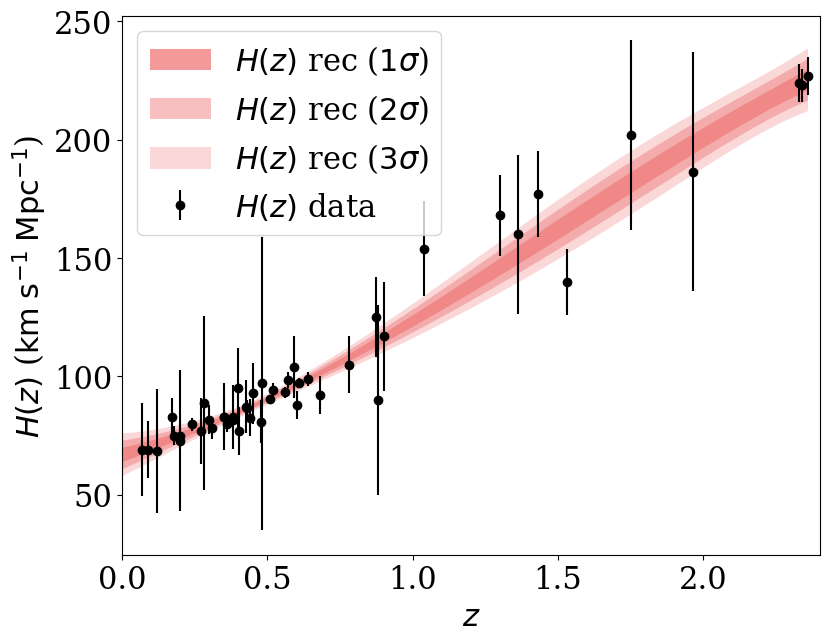

In [3]:
if __name__=="__main__":

    #======== loading cosmological data
    filename = 'hz_cc_sdss'
    (Z,Hz,Sigma,hid) = loadtxt(filename+'.dat',unpack='True')

    #======== Gaussian process: reconstructing H(z) from data, starting from zmin = 0 all the way to zmax from data 
    zmin = 0.
    zmax = np.max(Z)
    g1 = gp.GaussianProcess(Z,Hz,Sigma,covfunction=covariance.SquaredExponential,cXstar=(zmin,zmax,200))
    #g2 = gp.GaussianProcess(Z,Hz,Sigma,covfunction=covariance.DoubleSquaredExponential,cXstar=(zmin,zmax,200))
    #g3 = gp.GaussianProcess(Z,Hz,Sigma,covfunction=covariance.Matern92,cXstar=(zmin,zmax,200))
    #g4 = gp.GaussianProcess(Z,Hz,Sigma,covfunction=covariance.Matern72,cXstar=(zmin,zmax,200))
    #g5 = gp.GaussianProcess(Z,Hz,Sigma,covfunction=covariance.Matern52,cXstar=(zmin,zmax,200))
    #g6 = gp.GaussianProcess(Z,Hz,Sigma,covfunction=covariance.Matern32,cXstar=(zmin,zmax,200))
    (rec1,theta1) = g1.gp(thetatrain='True')
    #(rec2,theta2) = g2.gp(thetatrain='True')
    #(rec3,theta3) = g3.gp(thetatrain='True')
    #(rec4,theta4) = g4.gp(thetatrain='True')
    #(rec5,theta5) = g5.gp(thetatrain='True')
    #(rec6,theta6) = g6.gp(thetatrain='True')
    
    #====== reconstrucing the dH(z) and d2H(z) from data - not necessary when measuring H0
    #(drec,theta) = g.dgp(thetatrain='False')
    #(d2rec,theta) = g.d2gp()

    #===== creating variables to receive the GP reconstructed Hz 
    zrec = rec1[:,0]
    hzrec = rec1[:,1]
    sighzrec = rec1[:,2]
    
    # ======= printing the reconstructed H(z) at the lowest point, i.e., zmin=0, and its relative uncertainty 
    print('z=', zrec[0], ' H0=', hzrec[0], ' sigH0=',  sighzrec[0], ' sigH0/H0 (%)=', (sighzrec[0]/hzrec[0])*100.)
        
    # ========== saving the reconstructed hz and its derivatives
    savetxt("hz_rec.dat",rec1)
    #savetxt("dh_rec.txt",drec)
    #savetxt("d2h_rec.txt",d2rec)
    ####################################################################################################
    # ======= OPTIONAL: plotting the reconstructed hz curve
    #latex rendering text fonts
    plt.rc('text', usetex=False)
    plt.rc('font', family='serif')

    # ====== Create figure size in inches
    fig, ax = plt.subplots(figsize = (9., 7.))

    # ========= Define axes
    ax.set_xlabel(r"$z$", fontsize=22)
    ax.set_ylabel(r"$H(z)$ ($\mathrm{km} \; \mathrm{s}^{-1} \; \mathrm{Mpc}^{-1}$)", fontsize=22)
    plt.xlim(zmin, 2.4)
    for t in ax.get_xticklabels(): t.set_fontsize(22)
    for t in ax.get_yticklabels(): t.set_fontsize(22)
    
    # ========== Plotting the real data points and reconstructed H(z) curves - from 1 to 3sigma
    plt.errorbar(Z, Hz, yerr=Sigma, fmt='o', color='black')
    ax.fill_between(zrec, hzrec+1.*sighzrec, hzrec-1.*sighzrec, facecolor='#F08080', alpha=0.80, interpolate=True)
    ax.fill_between(zrec, hzrec+2.*sighzrec, hzrec-2.*sighzrec, facecolor='#F08080', alpha=0.50, interpolate=True)
    ax.fill_between(zrec, hzrec+3.*sighzrec, hzrec-3.*sighzrec, facecolor='#F08080', alpha=0.30, interpolate=True)
    plt.legend((r"$H(z)$ rec ($1\sigma$)", "$H(z)$ rec ($2\sigma$)", "$H(z)$ rec ($3\sigma$)", "$H(z)$ data"), fontsize='22', loc='upper left')
    plt.show()

    # =========== saving the plot
    fig.savefig(filename + '_reconst.png')